 **Step 1-Connect Google Drive with Google Colab to access the project files.**


In [1]:
# ============================================
# MEMBER 3 - LOGSENTRY LIMITATION ANALYSIS
# Step 1: Connect Google Drive to Google Colab
# ============================================

# This allows Google Colab to access files
# that are stored in your Google Drive.

from google.colab import drive

# Mount (connect) Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


**Step 2-Check whether all three required Member 1  files are successfully available in Google Colab.**


In [2]:
# ==========================================================
# MEMBER 3 - STEP 2
# Check whether all required files are available
# ==========================================================

# "os" lets Python check files and folders
import os

# Paths of the three files uploaded to this Colab session
input_file = "/content/deeplog_input.txt"
labels_file = "/content/deeplog_labels.txt"
templates_file = "/content/templates.csv"

# Put all file paths in a list
files = [input_file, labels_file, templates_file]

print("Checking Member 1 files...\n")

# Check each file one by one
for file in files:

    # os.path.exists() checks whether the file is present
    if os.path.exists(file):
        print("FOUND:", file)
    else:
        print("NOT FOUND:", file)

print("\nFile checking completed.")

Checking Member 1 files...

FOUND: /content/deeplog_input.txt
FOUND: /content/deeplog_labels.txt
FOUND: /content/templates.csv

File checking completed.


 **Step 3- Verify the dataset by checking the number of sequences, labels, templates, and their alignment.**

In [3]:
# ==========================================================
# MEMBER 3 - STEP 3
# Basic Dataset Verification
# ==========================================================

# pandas helps us read CSV and text data easily
import pandas as pd

print("Reading the dataset... Please wait.\n")


# ----------------------------------------------------------
# 1. Count the number of log sequences
# ----------------------------------------------------------

# Start the sequence count from 0
sequence_count = 0

# Open the DeepLog input file
# Each non-empty line represents one HDFS block sequence
with open("/content/deeplog_input.txt", "r") as file:

    for line in file:

        # Count the line only if it is not empty
        if line.strip():
            sequence_count += 1


# ----------------------------------------------------------
# 2. Read the labels file
# ----------------------------------------------------------

# This file contains the block ID and its label
# Label can be Normal or Anomaly
labels = pd.read_csv("/content/deeplog_labels.txt")


# ----------------------------------------------------------
# 3. Read the templates file
# ----------------------------------------------------------

# This file contains the log key and its corresponding template
templates = pd.read_csv("/content/templates.csv")


# ----------------------------------------------------------
# 4. Display basic dataset information
# ----------------------------------------------------------

print("========== DATASET SUMMARY ==========")

print("Number of sequences :", sequence_count)
print("Number of labels    :", len(labels))
print("Number of templates :", len(templates))


# ----------------------------------------------------------
# 5. Count Normal and Anomaly labels
# ----------------------------------------------------------

print("\n========== LABEL COUNTS ==========")

print(labels["label"].value_counts())


# ----------------------------------------------------------
# 6. Check whether sequences and labels are aligned
# ----------------------------------------------------------

print("\n========== ALIGNMENT CHECK ==========")

# Every sequence should have exactly one label
if sequence_count == len(labels):
    print("PASS: Every sequence has a corresponding label.")
else:
    print("WARNING: Number of sequences and labels do not match!")


# ----------------------------------------------------------
# 7. Display the first 5 templates
# ----------------------------------------------------------

print("\n========== FIRST 5 TEMPLATES ==========")

print(templates.head())


# Final message
print("\nDataset verification completed.")

Reading the dataset... Please wait.

========== DATASET SUMMARY ==========
Number of sequences : 575061
Number of labels    : 575061
Number of templates : 34

========== LABEL COUNTS ==========
label
Normal     558223
Anomaly     16838
Name: count, dtype: int64

========== ALIGNMENT CHECK ==========
PASS: Every sequence has a corresponding label.

========== FIRST 5 TEMPLATES ==========
   log_key                                           template
0        1  DATE NUM NUM INFO dfs.DataNode$DataXceiver: Re...
1        2              DATE NUM NUM INFO <*> <*> <*> <*> BLK
2        3  DATE NUM NUM INFO dfs.DataNode$PacketResponder...
3        4  DATE NUM NUM INFO dfs.DataNode$PacketResponder...
4        5  DATE NUM NUM INFO dfs.FSNamesystem: BLOCK* Nam...

Dataset verification completed.


**Step 4- Count how frequently each log key appears in the dataset to help select suitable templates for the unseen-template experiment.**

In [4]:
# ==========================================================
# MEMBER 3 - STEP 4
# Template Frequency Analysis
# ==========================================================

# Counter helps us count how many times each log key appears
from collections import Counter

# This will store the frequency of every log key
log_key_counts = Counter()

# This will count the total number of log events
total_log_events = 0

print("Counting log key frequencies... Please wait.\n")


# ----------------------------------------------------------
# 1. Read every sequence from deeplog_input.txt
# ----------------------------------------------------------

with open("/content/deeplog_input.txt", "r") as file:

    # Read the file one sequence at a time
    for line in file:

        # Remove extra spaces/newline
        line = line.strip()

        # Ignore empty lines
        if not line:
            continue

        # Convert the log keys from text into integers
        # Example: "1 3 4 5" becomes [1, 3, 4, 5]
        keys = [int(key) for key in line.split()]

        # Add these keys to our frequency counter
        log_key_counts.update(keys)

        # Add the number of events in this sequence
        total_log_events += len(keys)


# ----------------------------------------------------------
# 2. Display total number of log events
# ----------------------------------------------------------

print("Total log events:", total_log_events)


# ----------------------------------------------------------
# 3. Display frequency of every log key
# ----------------------------------------------------------

print("\n========== LOG KEY FREQUENCIES ==========")

print(f"{'Log Key':<10} {'Count':<15} {'Percentage':<12}")
print("-" * 40)

# Display keys from 1 to 34 in numerical order
for log_key in range(1, 35):

    # Get frequency of this key
    count = log_key_counts[log_key]

    # Calculate percentage of total log events
    percentage = (count / total_log_events) * 100

    # Display the result
    print(f"{log_key:<10} {count:<15} {percentage:.4f}%")


# ----------------------------------------------------------
# 4. Check how many unique log keys were found
# ----------------------------------------------------------

print("\nUnique log keys found:", len(log_key_counts))

print("\nTemplate frequency analysis completed.")

Counting log key frequencies... Please wait.

Total log events: 11175629

========== LOG KEY FREQUENCIES ==========
Log Key    Count           Percentage  
----------------------------------------
1          1723232         15.4196%
2          695097          6.2198%
3          1706728         15.2719%
4          1706514         15.2700%
5          1719741         15.3883%
6          7097            0.0635%
7          1409080         12.6085%
8          330             0.0030%
9          428726          3.8363%
10         6994            0.0626%
11         3226            0.0289%
12         1474            0.0132%
13         75              0.0007%
14         80              0.0007%
15         975             0.0087%
16         37              0.0003%
17         40              0.0004%
18         90              0.0008%
19         65              0.0006%
20         16              0.0001%
21         22              0.0002%
22         9               0.0001%
23         9               0

**Step 5-Classify log templates by their frequency to help select balanced and meaningful held-out templates for the unseen-template experiment.**

In [5]:
# ==========================================================
# MEMBER 3 - STEP 5
# Classify Log Templates Based on Frequency
# ==========================================================

print("Classifying log templates based on frequency...\n")


# ----------------------------------------------------------
# 1. Create groups for different frequency levels
# ----------------------------------------------------------

# These lists will store log keys based on how often they appear
very_frequent_keys = []
medium_keys = []
rare_keys = []
very_rare_keys = []


# ----------------------------------------------------------
# 2. Check the frequency of every log key
# ----------------------------------------------------------

for log_key in range(1, 35):

    # Get the number of times this log key appears
    count = log_key_counts[log_key]

    # Calculate its percentage in the complete dataset
    percentage = (count / total_log_events) * 100


    # ------------------------------------------------------
    # Put the key into a frequency group
    # ------------------------------------------------------

    # Very Frequent:
    # Appears in 1% or more of all log events
    if percentage >= 1:
        very_frequent_keys.append(log_key)

    # Medium:
    # Appears from 0.01% to less than 1%
    elif percentage >= 0.01:
        medium_keys.append(log_key)

    # Rare:
    # Appears from 0.001% to less than 0.01%
    elif percentage >= 0.001:
        rare_keys.append(log_key)

    # Very Rare:
    # Appears in less than 0.001% of all log events
    else:
        very_rare_keys.append(log_key)


# ----------------------------------------------------------
# 3. Display the groups
# ----------------------------------------------------------

print("========== FREQUENCY GROUPS ==========\n")

print("Very Frequent Keys (>= 1%):")
print(very_frequent_keys)

print("\nMedium Keys (>= 0.01% and < 1%):")
print(medium_keys)

print("\nRare Keys (>= 0.001% and < 0.01%):")
print(rare_keys)

print("\nVery Rare Keys (< 0.001%):")
print(very_rare_keys)


# ----------------------------------------------------------
# 4. Display number of templates in each group
# ----------------------------------------------------------

print("\n========== NUMBER OF TEMPLATES ==========")

print("Very Frequent :", len(very_frequent_keys))
print("Medium        :", len(medium_keys))
print("Rare          :", len(rare_keys))
print("Very Rare     :", len(very_rare_keys))


# ----------------------------------------------------------
# 5. Final check
# ----------------------------------------------------------

total_classified = (
    len(very_frequent_keys)
    + len(medium_keys)
    + len(rare_keys)
    + len(very_rare_keys)
)

print("\nTotal templates classified:", total_classified)

if total_classified == 34:
    print("PASS: All 34 templates were classified successfully.")
else:
    print("WARNING: Some templates were not classified.")

print("\nFrequency classification completed.")

Classifying log templates based on frequency...

========== FREQUENCY GROUPS ==========

Very Frequent Keys (>= 1%):
[1, 2, 3, 4, 5, 7, 9, 24, 27]

Medium Keys (>= 0.01% and < 1%):
[6, 10, 11, 12, 25, 26]

Rare Keys (>= 0.001% and < 0.01%):
[8, 15]

Very Rare Keys (< 0.001%):
[13, 14, 16, 17, 18, 19, 20, 21, 22, 23, 28, 29, 30, 31, 32, 33, 34]

========== NUMBER OF TEMPLATES ==========
Very Frequent : 9
Medium        : 6
Rare          : 2
Very Rare     : 17

Total templates classified: 34
PASS: All 34 templates were classified successfully.

Frequency classification completed.


**Step 6 — Select candidate templates for the concept-drift experiment**

In [6]:
# STEP 6: Select candidate templates for the seen/unseen experiment

# We prefer Medium and Rare templates because:
# Very Frequent templates may affect too much training data.
# Very Rare templates may not provide enough examples.

candidate_keys = medium_keys + rare_keys

print("Candidate log keys:", candidate_keys)
print("Number of candidate keys:", len(candidate_keys))

print("\nCandidate key frequencies:")

for key in candidate_keys:
    count = log_key_counts[key]
    percentage = (count / total_log_events) * 100

    print(
        f"Log Key {key}: "
        f"{count:,} events "
        f"({percentage:.4f}%)"
    )

Candidate log keys: [6, 10, 11, 12, 25, 26, 8, 15]
Number of candidate keys: 8

Candidate key frequencies:
Log Key 6: 7,097 events (0.0635%)
Log Key 10: 6,994 events (0.0626%)
Log Key 11: 3,226 events (0.0289%)
Log Key 12: 1,474 events (0.0132%)
Log Key 25: 5,545 events (0.0496%)
Log Key 26: 1,288 events (0.0115%)
Log Key 8: 330 events (0.0030%)
Log Key 15: 975 events (0.0087%)


**Step 7-Check how often each candidate log key appears in Normal and Anomaly sequences before selecting held-out templates.**

In [7]:
# STEP 7: Check candidate keys in Normal and Anomaly sequences

from collections import Counter

normal_counts = Counter()
anomaly_counts = Counter()

# Read sequences and their labels together
with open("/content/deeplog_input.txt", "r") as file:
    sequences = [line.strip() for line in file if line.strip()]

# Check every sequence
for sequence, label in zip(sequences, labels["label"]):

    keys = [int(key) for key in sequence.split()]

    for key in candidate_keys:

        if key in keys:

            if label == "Normal":
                normal_counts[key] += 1

            elif label == "Anomaly":
                anomaly_counts[key] += 1

# Display results
print("Candidate Key | Normal Sequences | Anomaly Sequences")
print("-" * 52)

for key in candidate_keys:
    print(
        f"{key:<13} | "
        f"{normal_counts[key]:<16} | "
        f"{anomaly_counts[key]}"
    )

Candidate Key | Normal Sequences | Anomaly Sequences
----------------------------------------------------
6             | 1778             | 3465
10            | 1769             | 3423
11            | 0                | 3226
12            | 0                | 493
25            | 219              | 5126
26            | 12               | 1247
8             | 26               | 75
15            | 3                | 971


**Step 8- Check whether candidate Log Keys 6 and 10 occur in the same Normal sequences before selecting the final held-out template.**

In [8]:
# STEP 8: Check overlap between Log Keys 6 and 10

key6_normal = 0
key10_normal = 0
both_normal = 0

for sequence, label in zip(sequences, labels["label"]):

    if label == "Normal":

        keys = [int(key) for key in sequence.split()]

        has_6 = 6 in keys
        has_10 = 10 in keys

        if has_6:
            key6_normal += 1

        if has_10:
            key10_normal += 1

        if has_6 and has_10:
            both_normal += 1

print("Normal sequences containing Log Key 6 :", key6_normal)
print("Normal sequences containing Log Key 10:", key10_normal)
print("Normal sequences containing both 6 and 10:", both_normal)

print("\nOnly Log Key 6 :", key6_normal - both_normal)
print("Only Log Key 10:", key10_normal - both_normal)

Normal sequences containing Log Key 6 : 1778
Normal sequences containing Log Key 10: 1769
Normal sequences containing both 6 and 10: 1768

Only Log Key 6 : 10
Only Log Key 10: 1


**Step 9-Display the actual log template represented by Log Key 6 before selecting it as the held-out template.**

In [9]:
# STEP 9: Display the template for Log Key 6

selected_key = 6

template_info = templates[templates["log_key"] == selected_key]

print("Selected Log Key:", selected_key)
print("\nTemplate:")
print(template_info["template"].iloc[0])

Selected Log Key: 6

Template:
DATE NUM NUM INFO dfs.DataNode$DataXceiver: Received block BLK src: IP dest: IP of size <*>


**Step 10-Separate Normal sequences containing Log Key 6 as the held-out set for the concept-drift experiment.**

In [10]:
# STEP 10: Create held-out normal set using Log Key 6

held_out_key = 6

held_out_sequences = []
remaining_normal_sequences = []

for sequence, label in zip(sequences, labels["label"]):

    if label == "Normal":

        keys = [int(key) for key in sequence.split()]

        if held_out_key in keys:
            held_out_sequences.append(sequence)
        else:
            remaining_normal_sequences.append(sequence)

print("Held-out Log Key:", held_out_key)
print("Normal sequences containing Key 6:", len(held_out_sequences))
print("Remaining Normal sequences:", len(remaining_normal_sequences))

print("\nTotal Normal sequences:",
      len(held_out_sequences) + len(remaining_normal_sequences))

Held-out Log Key: 6
Normal sequences containing Key 6: 1778
Remaining Normal sequences: 556445

Total Normal sequences: 558223


**Step 11-Create modified Normal training data by excluding the held-out sequences containing Log Key 6.**

In [11]:
# STEP 11: Create modified training data without held-out Key 6

modified_training_sequences = remaining_normal_sequences

print("Held-out Log Key:", held_out_key)
print("Original Normal sequences:", len(held_out_sequences) +
      len(modified_training_sequences))
print("Removed held-out sequences:", len(held_out_sequences))
print("Modified Normal sequences:", len(modified_training_sequences))

# Final check: Key 6 should not appear in modified training data
key6_found = 0

for sequence in modified_training_sequences:
    keys = [int(key) for key in sequence.split()]

    if held_out_key in keys:
        key6_found += 1

print("\nSequences containing Key 6 after removal:", key6_found)

if key6_found == 0:
    print("PASS: Log Key 6 is completely held out.")
else:
    print("CHECK: Log Key 6 is still present.")

Held-out Log Key: 6
Original Normal sequences: 558223
Removed held-out sequences: 1778
Modified Normal sequences: 556445

Sequences containing Key 6 after removal: 0
PASS: Log Key 6 is completely held out.


 **Step 12 -Check the selected Log Key 6 and its template information before linking it with the baseline DeepLog event representation.**

In [12]:
# STEP 12: Verify selected Log Key 6

selected_key = 6

selected_template = templates[
    templates["log_key"] == selected_key
]

print("Selected Log Key:", selected_key)
print("Template:")
print(selected_template["template"].iloc[0])

print("\nMember 3 representation:", selected_key)
print("Baseline representation must be verified before retraining.")

Selected Log Key: 6
Template:
DATE NUM NUM INFO dfs.DataNode$DataXceiver: Received block BLK src: IP dest: IP of size <*>

Member 3 representation: 6
Baseline representation must be verified before retraining.


**Step 13 - Load the Event_traces.csv file used by the baseline DeepLog model and verify its structure.**

In [13]:
# STEP 13: Load and verify Event_traces.csv

import pandas as pd

event_df = pd.read_csv("/content/Event_traces.csv")

print("Shape:", event_df.shape)
print("Columns:", event_df.columns.tolist())

print("\nFirst 5 rows:")
display(event_df.head())

Shape: (575061, 6)
Columns: ['BlockId', 'Label', 'Type', 'Features', 'TimeInterval', 'Latency']

First 5 rows:


,BlockId,Label,Type,Features,TimeInterval,Latency
0,blk_-1608999687919862906,Success,NaN,"[E5,E22,E5,E5,E11,E11,E9,E9,E11,E9,E26,E26,E26...","[0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",3802
1,blk_7503483334202473044,Success,NaN,"[E5,E5,E22,E5,E11,E9,E11,E9,E11,E9,E26,E26,E26...","[0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",3802
2,blk_-3544583377289625738,Fail,21.0,"[E5,E22,E5,E5,E11,E9,E11,E9,E11,E9,E3,E26,E26,...","[0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, ...",3797
3,blk_-9073992586687739851,Success,NaN,"[E5,E22,E5,E5,E11,E9,E11,E9,E11,E9,E26,E26,E26...","[0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",50448
4,blk_7854771516489510256,Success,NaN,"[E5,E5,E22,E5,E11,E9,E11,E9,E11,E9,E26,E26,E26...","[0.0, 0.0, 1.0, 48.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",50583


**Step 14 - Compare the two sequence representations to identify the baseline Event ID corresponding to Log Key 6.**

In [14]:
# STEP 14: Map numeric Log Keys to baseline Event IDs

from collections import defaultdict, Counter

# Load Member 1 numeric sequences
with open("/content/deeplog_input.txt", "r") as f:
    numeric_sequences = [
        list(map(int, line.strip().split()))
        for line in f if line.strip()
    ]

# Convert baseline Features like [E5,E22,E5,...] into a list
def parse_events(value):
    value = str(value).strip()
    if value.startswith("[") and value.endswith("]"):
        return [x.strip() for x in value[1:-1].split(",") if x.strip()]
    return []

mapping_counts = defaultdict(Counter)

matched_rows = 0
length_mismatches = 0

for nums, feature in zip(numeric_sequences, event_df["Features"]):
    events = parse_events(feature)

    if len(nums) != len(events):
        length_mismatches += 1
        continue

    matched_rows += 1

    for log_key, event_id in zip(nums, events):
        mapping_counts[log_key][event_id] += 1

print("Rows with matching sequence length:", matched_rows)
print("Rows with length mismatch:", length_mismatches)

print("\nMapping candidates for Log Key 6:")
print(mapping_counts[6].most_common(10))

Rows with matching sequence length: 575061
Rows with length mismatch: 0

Mapping candidates for Log Key 6:
[('E6', 7097)]


**Step 15 - Verify that every numeric Log Key consistently maps to one baseline Event ID**

In [15]:
# STEP 15: Verify complete Log Key to Event ID mapping

print("Log Key -> Event ID mapping\n")

for log_key in sorted(mapping_counts.keys()):
    total = sum(mapping_counts[log_key].values())
    best_event, best_count = mapping_counts[log_key].most_common(1)[0]

    confidence = best_count / total * 100

    print(
        f"Log Key {log_key:2d} -> {best_event:4s} "
        f"| Matches: {best_count}/{total} "
        f"| Confidence: {confidence:.2f}%"
    )

Log Key -> Event ID mapping

Log Key  1 -> E5   | Matches: 1723232/1723232 | Confidence: 100.00%
Log Key  2 -> E22  | Matches: 575061/695097 | Confidence: 82.73%
Log Key  3 -> E11  | Matches: 1706679/1706728 | Confidence: 100.00%
Log Key  4 -> E9   | Matches: 1706514/1706514 | Confidence: 100.00%
Log Key  5 -> E26  | Matches: 1719741/1719741 | Confidence: 100.00%
Log Key  6 -> E6   | Matches: 7097/7097 | Confidence: 100.00%
Log Key  7 -> E21  | Matches: 1402047/1409080 | Confidence: 99.50%
Log Key  8 -> E18  | Matches: 165/330 | Confidence: 50.00%
Log Key  9 -> E3   | Matches: 428726/428726 | Confidence: 100.00%
Log Key 10 -> E18  | Matches: 6837/6994 | Confidence: 97.76%
Log Key 11 -> E7   | Matches: 3226/3226 | Confidence: 100.00%
Log Key 12 -> E13  | Matches: 1464/1474 | Confidence: 99.32%
Log Key 13 -> E14  | Matches: 75/75 | Confidence: 100.00%
Log Key 14 -> E7   | Matches: 67/80 | Confidence: 83.75%
Log Key 15 -> E27  | Matches: 975/975 | Confidence: 100.00%
Log Key 16 -> E10  | 

**Step 16 - Reproduce the baseline DeepLog 80/20 train-test split using the same random seed and label stratification.**

In [16]:
# STEP 16: Reproduce Member 2 baseline train-test split

from sklearn.model_selection import train_test_split

SEED = 42

train_df, test_df = train_test_split(
    event_df,
    test_size=0.20,
    random_state=SEED,
    stratify=event_df["Label"]
)

print("Total sequences:", len(event_df))
print("Training sequences:", len(train_df))
print("Testing sequences:", len(test_df))

print("\nTraining labels:")
print(train_df["Label"].value_counts())

print("\nTesting labels:")
print(test_df["Label"].value_counts())

Total sequences: 575061
Training sequences: 460048
Testing sequences: 115013

Training labels:
Label
Success    446578
Fail        13470
Name: count, dtype: int64

Testing labels:
Label
Success    111645
Fail         3368
Name: count, dtype: int64


**Step 17 - Count the normal sequences containing the selected E6 event in the baseline training and testing sets.**

In [17]:
# STEP 17: Count normal sequences containing E6

def contains_e6(feature):
    events = parse_events(feature)
    return "E6" in events

# Normal sequences only
train_normal = train_df[train_df["Label"] == "Success"].copy()
test_normal = test_df[test_df["Label"] == "Success"].copy()

# Find E6
train_normal["contains_E6"] = train_normal["Features"].apply(contains_e6)
test_normal["contains_E6"] = test_normal["Features"].apply(contains_e6)

print("Normal training sequences:", len(train_normal))
print("Normal training sequences containing E6:",
      train_normal["contains_E6"].sum())

print("\nNormal testing sequences:", len(test_normal))
print("Normal testing sequences containing E6:",
      test_normal["contains_E6"].sum())

print("\nTotal normal E6 sequences:",
      train_normal["contains_E6"].sum()
      + test_normal["contains_E6"].sum())

Normal training sequences: 446578
Normal training sequences containing E6: 1443

Normal testing sequences: 111645
Normal testing sequences containing E6: 335

Total normal E6 sequences: 1778


**Step 18 - Remove normal training sequences containing E6 to create the controlled held-out training dataset.**

In [18]:
# STEP 18: Remove E6 from normal training data

heldout_train_normal = train_normal[
    ~train_normal["contains_E6"]
].copy()

print("Original normal training sequences:", len(train_normal))
print("Removed E6 normal sequences:",
      train_normal["contains_E6"].sum())
print("Remaining normal training sequences:",
      len(heldout_train_normal))

# Verify E6 is absent
remaining_e6 = heldout_train_normal["Features"].apply(
    contains_e6
).sum()

print("\nE6 sequences remaining in training:", remaining_e6)

if remaining_e6 == 0:
    print("Verification: PASS - E6 is completely hidden from normal training.")
else:
    print("Verification: FAIL")

Original normal training sequences: 446578
Removed E6 normal sequences: 1443
Remaining normal training sequences: 445135

E6 sequences remaining in training: 0
Verification: PASS - E6 is completely hidden from normal training.


**Step 19 - Separate the normal E6 test sequences that will be used to measure false-positive behaviour on unseen legitimate patterns.**

In [19]:
# STEP 19: Create the unseen normal E6 test group

unseen_normal_test = test_normal[
    test_normal["contains_E6"]
].copy()

seen_normal_test = test_normal[
    ~test_normal["contains_E6"]
].copy()

print("Total normal test sequences:", len(test_normal))
print("Seen normal test sequences:", len(seen_normal_test))
print("Unseen E6 normal test sequences:", len(unseen_normal_test))

print("\nCheck:")
print(
    "Total:",
    len(seen_normal_test) + len(unseen_normal_test)
)

if len(unseen_normal_test) == 335:
    print("Verification: PASS - unseen E6 test group created correctly.")
else:
    print("Verification: CHECK REQUIRED")

Total normal test sequences: 111645
Seen normal test sequences: 111310
Unseen E6 normal test sequences: 335

Check:
Total: 111645
Verification: PASS - unseen E6 test group created correctly.


**Step 20 - Create the same event-to-integer encoding used by the baseline DeepLog model.**

In [22]:
# STEP 20: Create the same event encoding as Member 2

# Collect all unique Event IDs
unique_events = sorted(
    set(
        event
        for feature in event_df["Features"]
        for event in parse_events(feature)
    )
)

# Create Event ID -> Integer mapping
event_to_int = {
    event_id: index + 1
    for index, event_id in enumerate(unique_events)
}

int_to_event = {
    index: event_id
    for event_id, index in event_to_int.items()
}

print("Number of unique Event IDs:", len(unique_events))

print("\nEvent-to-integer mapping:")
print(event_to_int)

print("\nHeld-out event mapping:")
print("E6 ->", event_to_int["E6"])

Number of unique Event IDs: 29

Event-to-integer mapping:
{'E1': 1, 'E10': 2, 'E11': 3, 'E12': 4, 'E13': 5, 'E14': 6, 'E15': 7, 'E16': 8, 'E17': 9, 'E18': 10, 'E19': 11, 'E2': 12, 'E20': 13, 'E21': 14, 'E22': 15, 'E23': 16, 'E24': 17, 'E25': 18, 'E26': 19, 'E27': 20, 'E28': 21, 'E29': 22, 'E3': 23, 'E4': 24, 'E5': 25, 'E6': 26, 'E7': 27, 'E8': 28, 'E9': 29}

Held-out event mapping:
E6 -> 26


**Step 21 - Generate DeepLog training windows using the baseline event encoding and verify that the held-out E6 event remains unseen during training.**

In [23]:
# STEP 21: Generate correctly encoded training windows

WINDOW_SIZE = 20
HELDOUT_EVENT = "E6"
HELDOUT_ID = event_to_int[HELDOUT_EVENT]

X_train = []
y_train = []

for feature in heldout_train_normal["Features"]:
    events = parse_events(feature)

    # Use Member 2's exact event-to-integer mapping
    encoded_events = [event_to_int[event] for event in events]

    if len(encoded_events) <= WINDOW_SIZE:
        continue

    for i in range(len(encoded_events) - WINDOW_SIZE):
        X_train.append(encoded_events[i:i + WINDOW_SIZE])
        y_train.append(encoded_events[i + WINDOW_SIZE])

# Verify held-out E6 is absent
e6_in_inputs = sum(HELDOUT_ID in window for window in X_train)
e6_in_targets = sum(target == HELDOUT_ID for target in y_train)

print("Window size:", WINDOW_SIZE)
print("Training windows:", len(X_train))
print("Target events:", len(y_train))

print("\nE6 encoded ID:", HELDOUT_ID)
print("Training windows containing E6:", e6_in_inputs)
print("Targets equal to E6:", e6_in_targets)

if e6_in_inputs == 0 and e6_in_targets == 0:
    print("\nVerification: PASS - E6 is completely unseen during training.")
else:
    print("\nVerification: FAIL")

Window size: 20
Training windows: 573302
Target events: 573302

E6 encoded ID: 26
Training windows containing E6: 0
Targets equal to E6: 0

Verification: PASS - E6 is completely unseen during training.


**Step 22 - Convert the correctly encoded training windows into PyTorch tensors and prepare the DataLoader for DeepLog training.**

In [24]:
# STEP 22: Prepare PyTorch training data

import torch
from torch.utils.data import TensorDataset, DataLoader

BATCH_SIZE = 256

# Convert training data to tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.long)

# CrossEntropyLoss uses class indexes starting from 0
y_train_tensor = torch.tensor(y_train, dtype=torch.long) - 1

# Create dataset and DataLoader
train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

print("X_train shape:", X_train_tensor.shape)
print("y_train shape:", y_train_tensor.shape)
print("Batch size:", BATCH_SIZE)
print("Number of batches:", len(train_loader))

print("\nTraining DataLoader created successfully.")

X_train shape: torch.Size([573302, 20])
y_train shape: torch.Size([573302])
Batch size: 256
Number of batches: 2240

Training DataLoader created successfully.


**Step 23 - Define the DeepLog LSTM model using the same architecture as the baseline model.**

In [25]:
# STEP 23: Define DeepLog LSTM model

import torch.nn as nn

NUM_EVENTS = len(unique_events)
EMBEDDING_DIM = 32
HIDDEN_SIZE = 64
NUM_LAYERS = 2

class DeepLogLSTM(nn.Module):
    def __init__(self):
        super(DeepLogLSTM, self).__init__()

        self.embedding = nn.Embedding(
            NUM_EVENTS + 1,
            EMBEDDING_DIM
        )

        self.lstm = nn.LSTM(
            EMBEDDING_DIM,
            HIDDEN_SIZE,
            NUM_LAYERS,
            batch_first=True
        )

        self.fc = nn.Linear(
            HIDDEN_SIZE,
            NUM_EVENTS
        )

    def forward(self, x):
        x = self.embedding(x)
        output, _ = self.lstm(x)
        output = output[:, -1, :]
        output = self.fc(output)
        return output

model = DeepLogLSTM()

print(model)

print("\nNumber of events:", NUM_EVENTS)
print("Embedding dimension:", EMBEDDING_DIM)
print("Hidden size:", HIDDEN_SIZE)
print("LSTM layers:", NUM_LAYERS)

DeepLogLSTM(
  (embedding): Embedding(30, 32)
  (lstm): LSTM(32, 64, num_layers=2, batch_first=True)
  (fc): Linear(in_features=64, out_features=29, bias=True)
)

Number of events: 29
Embedding dimension: 32
Hidden size: 64
LSTM layers: 2


**Step 24 - Configure the loss function and Adam optimizer using the same training settings as the baseline DeepLog model.**

In [26]:
# STEP 24: Configure DeepLog training

import torch.optim as optim

LEARNING_RATE = 0.001
EPOCHS = 5

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

print("Loss function:", criterion)
print("Optimizer: Adam")
print("Learning rate:", LEARNING_RATE)
print("Epochs:", EPOCHS)

Loss function: CrossEntropyLoss()
Optimizer: Adam
Learning rate: 0.001
Epochs: 5


**Step 25 - Train the DeepLog model for five epochs using the E6-free normal training data.**

In [27]:
# STEP 25: Train the held-out DeepLog model

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = model.to(device)

print("Device:", device)
print("Starting training...\n")

training_losses = []

for epoch in range(EPOCHS):

    model.train()
    total_loss = 0

    for X_batch, y_batch in train_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        outputs = model(X_batch)

        loss = criterion(outputs, y_batch)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    average_loss = total_loss / len(train_loader)
    training_losses.append(average_loss)

    print(
        f"Epoch {epoch + 1}/{EPOCHS} "
        f"- Loss: {average_loss:.4f}"
    )

print("\nTraining completed successfully.")

Device: cpu
Starting training...

Epoch 1/5 - Loss: 0.2154
Epoch 2/5 - Loss: 0.1161
Epoch 3/5 - Loss: 0.1104
Epoch 4/5 - Loss: 0.1082
Epoch 5/5 - Loss: 0.1068

Training completed successfully.


**Step 26 - Save the trained E6-held-out DeepLog model for later evaluation and reuse.**

In [28]:
# STEP 26: Save trained held-out DeepLog model

MODEL_PATH = "/content/deeplog_e6_heldout.pth"

torch.save(model.state_dict(), MODEL_PATH)

print("Model saved successfully.")
print("Saved at:", MODEL_PATH)

Model saved successfully.
Saved at: /content/deeplog_e6_heldout.pth


**Step 27 - Prepare the seen-normal and unseen-E6 test groups for controlled DeepLog evaluation.**

In [29]:
# STEP 27: Prepare test groups for evaluation

TOP_K = 5

# Normal test sequences without E6
seen_test_df = test_normal[
    ~test_normal["contains_E6"]
].copy()

# Normal test sequences containing the unseen E6 event
unseen_e6_test_df = test_normal[
    test_normal["contains_E6"]
].copy()

print("Top-K:", TOP_K)
print("Seen normal test sequences:", len(seen_test_df))
print("Unseen E6 normal test sequences:", len(unseen_e6_test_df))

print("\nTotal normal test sequences:",
      len(seen_test_df) + len(unseen_e6_test_df))

if (
    len(seen_test_df) == 111310
    and len(unseen_e6_test_df) == 335
):
    print("Verification: PASS - evaluation groups are ready.")
else:
    print("Verification: CHECK REQUIRED")

Top-K: 5
Seen normal test sequences: 111310
Unseen E6 normal test sequences: 335

Total normal test sequences: 111645
Verification: PASS - evaluation groups are ready.


**Step 28 - Define the Top-5 DeepLog evaluation function to classify each normal test block as normal or falsely flagged as anomalous.**

In [30]:
# STEP 28: Define Top-5 block evaluation function

def evaluate_normal_blocks(dataframe, model, event_to_int,
                           window_size=20, top_k=5):

    model.eval()

    total_blocks = 0
    eligible_blocks = 0
    false_positive_blocks = 0

    with torch.no_grad():

        for feature in dataframe["Features"]:

            events = parse_events(feature)

            # Same encoding used during training
            encoded = [event_to_int[event] for event in events]

            total_blocks += 1

            # DeepLog needs at least 20 previous events + 1 target
            if len(encoded) <= window_size:
                continue

            eligible_blocks += 1
            block_flagged = False

            for i in range(len(encoded) - window_size):

                window = encoded[i:i + window_size]
                actual_next = encoded[i + window_size]

                x = torch.tensor(
                    [window],
                    dtype=torch.long,
                    device=device
                )

                outputs = model(x)

                # Output class 0 corresponds to encoded event ID 1
                top_predictions = torch.topk(
                    outputs,
                    k=top_k,
                    dim=1
                ).indices[0] + 1

                if actual_next not in top_predictions.tolist():
                    block_flagged = True
                    break

            if block_flagged:
                false_positive_blocks += 1

    return {
        "total_blocks": total_blocks,
        "eligible_blocks": eligible_blocks,
        "false_positive_blocks": false_positive_blocks
    }


print("Top-5 evaluation function created successfully.")

Top-5 evaluation function created successfully.


**Step 29 - Evaluate the trained DeepLog model on seen-normal and unseen-E6 normal test sequences and compare their false-positive rates.**

In [31]:
# STEP 29: Evaluate seen vs unseen-E6 normal test sequences

print("Evaluating seen normal test sequences...")
seen_results = evaluate_normal_blocks(
    seen_test_df,
    model,
    event_to_int,
    window_size=WINDOW_SIZE,
    top_k=TOP_K
)

print("Evaluating unseen E6 normal test sequences...")
unseen_results = evaluate_normal_blocks(
    unseen_e6_test_df,
    model,
    event_to_int,
    window_size=WINDOW_SIZE,
    top_k=TOP_K
)

# Calculate false-positive rates using eligible blocks
seen_fpr = (
    seen_results["false_positive_blocks"]
    / seen_results["eligible_blocks"] * 100
    if seen_results["eligible_blocks"] > 0 else 0
)

unseen_fpr = (
    unseen_results["false_positive_blocks"]
    / unseen_results["eligible_blocks"] * 100
    if unseen_results["eligible_blocks"] > 0 else 0
)

print("\n--- Seen Normal Results ---")
print("Total blocks:", seen_results["total_blocks"])
print("Eligible blocks:", seen_results["eligible_blocks"])
print("False positives:", seen_results["false_positive_blocks"])
print(f"False-positive rate: {seen_fpr:.2f}%")

print("\n--- Unseen E6 Normal Results ---")
print("Total blocks:", unseen_results["total_blocks"])
print("Eligible blocks:", unseen_results["eligible_blocks"])
print("False positives:", unseen_results["false_positive_blocks"])
print(f"False-positive rate: {unseen_fpr:.2f}%")

Evaluating seen normal test sequences...
Evaluating unseen E6 normal test sequences...

--- Seen Normal Results ---
Total blocks: 111310
Eligible blocks: 26483
False positives: 0
False-positive rate: 0.00%

--- Unseen E6 Normal Results ---
Total blocks: 335
Eligible blocks: 302
False positives: 70
False-positive rate: 23.18%


**Step 30 - Summarize the false-positive increase caused by introducing the unseen E6 normal pattern.**

In [32]:
# STEP 30: Summarize concept-drift experiment results

fpr_increase = unseen_fpr - seen_fpr

print("=== Member 3 Concept-Drift Experiment Summary ===")

print("\nSeen normal test group:")
print("Eligible blocks:", seen_results["eligible_blocks"])
print("False positives:", seen_results["false_positive_blocks"])
print(f"False-positive rate: {seen_fpr:.2f}%")

print("\nUnseen E6 normal test group:")
print("Eligible blocks:", unseen_results["eligible_blocks"])
print("False positives:", unseen_results["false_positive_blocks"])
print(f"False-positive rate: {unseen_fpr:.2f}%")

print("\nFalse-positive rate increase:")
print(f"{fpr_increase:.2f} percentage points")

print(
    "\nConclusion: Introducing the unseen E6 normal pattern "
    "increased false-positive behaviour in the held-out DeepLog model."
)

=== Member 3 Concept-Drift Experiment Summary ===

Seen normal test group:
Eligible blocks: 26483
False positives: 0
False-positive rate: 0.00%

Unseen E6 normal test group:
Eligible blocks: 302
False positives: 70
False-positive rate: 23.18%

False-positive rate increase:
23.18 percentage points

Conclusion: Introducing the unseen E6 normal pattern increased false-positive behaviour in the held-out DeepLog model.


**Step 31 - Save the final seen-normal and unseen-E6 evaluation results as a CSV file for reporting and GitHub documentation.**

In [33]:
# STEP 31: Save final experiment results

import pandas as pd

results_df = pd.DataFrame({
    "Test_Group": [
        "Seen Normal",
        "Unseen E6 Normal"
    ],
    "Eligible_Blocks": [
        seen_results["eligible_blocks"],
        unseen_results["eligible_blocks"]
    ],
    "False_Positives": [
        seen_results["false_positive_blocks"],
        unseen_results["false_positive_blocks"]
    ],
    "False_Positive_Rate_Percent": [
        seen_fpr,
        unseen_fpr
    ]
})

RESULT_PATH = "/content/member3_concept_drift_results.csv"

results_df.to_csv(RESULT_PATH, index=False)

display(results_df)

print("\nResults saved successfully.")
print("Saved at:", RESULT_PATH)

,Test_Group,Eligible_Blocks,False_Positives,False_Positive_Rate_Percent
0,Seen Normal,26483,0,0.000000
1,Unseen E6 Normal,302,70,23.178808



Results saved successfully.
Saved at: /content/member3_concept_drift_results.csv


**Step 32 - Save the trained E6-held-out DeepLog model and final experiment results permanently in Google Drive.**

In [34]:
# STEP 32: Save important Member 3 outputs to Google Drive

import os
import shutil

SAVE_DIR = "/content/drive/MyDrive/LogSentry_Member3"

os.makedirs(SAVE_DIR, exist_ok=True)

# Copy trained model
shutil.copy(
    "/content/deeplog_e6_heldout.pth",
    SAVE_DIR + "/deeplog_e6_heldout.pth"
)

# Copy experiment results
shutil.copy(
    "/content/member3_concept_drift_results.csv",
    SAVE_DIR + "/member3_concept_drift_results.csv"
)

print("Member 3 files saved successfully.")
print("Saved folder:", SAVE_DIR)
print("\nFiles:")
print("- deeplog_e6_heldout.pth")
print("- member3_concept_drift_results.csv")

Member 3 files saved successfully.
Saved folder: /content/drive/MyDrive/LogSentry_Member3

Files:
- deeplog_e6_heldout.pth
- member3_concept_drift_results.csv


**Step 33 - Create a bar graph comparing the false-positive rates of seen-normal and unseen-E6 normal test sequences.**

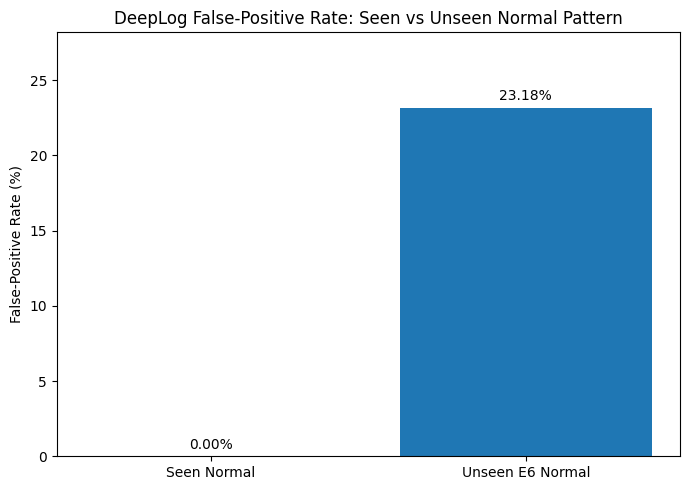


Graph saved successfully.
Saved at: /content/drive/MyDrive/LogSentry_Member3/seen_vs_unseen_fpr.png


In [35]:
# STEP 33: Plot false-positive rate comparison

import matplotlib.pyplot as plt

groups = ["Seen Normal", "Unseen E6 Normal"]
fpr_values = [seen_fpr, unseen_fpr]

plt.figure(figsize=(7, 5))

bars = plt.bar(groups, fpr_values)

plt.ylabel("False-Positive Rate (%)")
plt.title("DeepLog False-Positive Rate: Seen vs Unseen Normal Pattern")

# Display values above bars
for bar, value in zip(bars, fpr_values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{value:.2f}%",
        ha="center"
    )

plt.ylim(0, max(fpr_values) + 5)
plt.tight_layout()

GRAPH_PATH = (
    "/content/drive/MyDrive/LogSentry_Member3/"
    "seen_vs_unseen_fpr.png"
)

plt.savefig(GRAPH_PATH, dpi=300)
plt.show()

print("\nGraph saved successfully.")
print("Saved at:", GRAPH_PATH)


**Step 34 - Plot the training loss across five epochs to show the learning behaviour of the E6-held-out DeepLog model.**

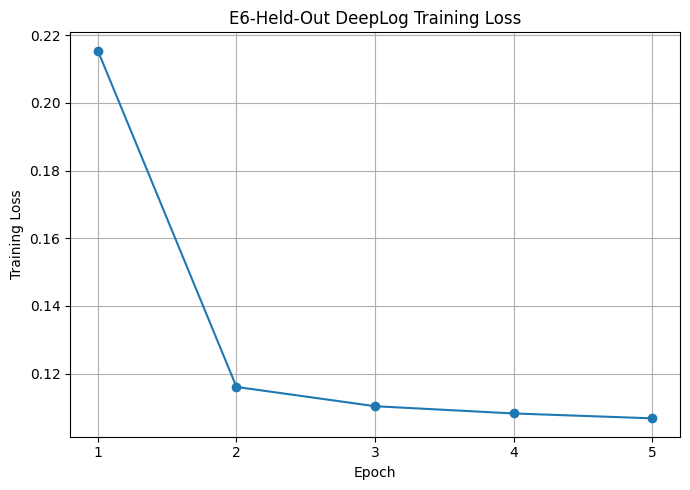


Training-loss graph saved successfully.
Saved at: /content/drive/MyDrive/LogSentry_Member3/training_loss.png


In [36]:
# STEP 34: Plot training loss

import matplotlib.pyplot as plt

epochs = range(1, len(training_losses) + 1)

plt.figure(figsize=(7, 5))
plt.plot(epochs, training_losses, marker="o")

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("E6-Held-Out DeepLog Training Loss")
plt.xticks(epochs)
plt.grid(True)
plt.tight_layout()

LOSS_GRAPH_PATH = (
    "/content/drive/MyDrive/LogSentry_Member3/"
    "training_loss.png"
)

plt.savefig(LOSS_GRAPH_PATH, dpi=300)
plt.show()

print("\nTraining-loss graph saved successfully.")
print("Saved at:", LOSS_GRAPH_PATH)